In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/clean/sales_data.csv')

df['total_new_sales'] = df['broadband'] + df['mobile'] + df['tv']
df['total_transactions'] = df['broadband'] + df['mobile'] + df['tv'] + df['regrades']
df['avg_hh_value'] = df['hh_value'] / df['hh_orders'].replace(0, np.nan)

TARGETS = {
    'hh_value':      28.50,
    'bb_conv':       0.1800,
    'mob_conv':      0.1420,
    'tv_conv':       0.0580,
    'combined_conv': 0.3220
}

print("Data loaded.")
print(f"Shape: {df.shape}")
df.head()

Data loaded.
Shape: (224, 12)


,team,calls,broadband,mobile,tv,regrades,hh_orders,hh_value,day,total_new_sales,total_transactions,avg_hh_value
0,Ben Traill,205.0,21.0,42.0,7.0,12.0,32.0,1051.13,1,70.0,82.0,32.847813
1,Beth Ogilvie,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1,0.0,0.0,NaN
2,Jack Inglis,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1,0.0,0.0,NaN
3,Joel Robertson,34.0,0.0,0.0,0.0,0.0,0.0,0.00,1,0.0,0.0,NaN
4,Paula Wilson,58.0,6.0,9.0,1.0,0.0,8.0,313.44,1,16.0,16.0,39.180000


In [2]:
# For anomaly detection we compare each team against THEIR OWN average
# Not against other teams - a quiet day for Ryan Watt might still be 
# a great day for Joel Robertson
# We use hh_value as the primary signal - it captures overall performance
# in a single number and is reliable at daily level unlike calls

team_baselines = df.groupby('team')['hh_value'].agg(
    mean_hh_value='mean',
    std_hh_value='std'
).reset_index()

print("Team baselines (daily HH value):")
print(team_baselines.round(2))

Team baselines (daily HH value):
             team  mean_hh_value  std_hh_value
0      Ben Traill         526.66        367.15
1    Beth Ogilvie         547.28        394.88
2     Jack Inglis         579.85        599.13
3  Joel Robertson         460.24        339.02
4    Paula Wilson         908.98        791.90
5    Reece Wright         425.74        303.26
6       Ryan Watt        1020.66        692.40
7    Scott Brodie         477.96        298.18


In [3]:
# Z-score = how many standard deviations a day is from that team's own mean
# Z > 2 = unusually good day
# Z < -2 = unusually bad day
# This is a standard statistical anomaly detection approach

df = df.merge(team_baselines, on='team')

df['hh_value_zscore'] = (df['hh_value'] - df['mean_hh_value']) / df['std_hh_value']

# Flag anomalies
df['is_high_anomaly'] = df['hh_value_zscore'] > 2
df['is_low_anomaly']  = df['hh_value_zscore'] < -2

high_anomalies = df[df['is_high_anomaly']][['team', 'day', 'hh_value', 'hh_value_zscore']].sort_values('hh_value_zscore', ascending=False)
low_anomalies  = df[df['is_low_anomaly']][['team', 'day', 'hh_value', 'hh_value_zscore']].sort_values('hh_value_zscore')

print(f"Unusually HIGH days (z > 2): {len(high_anomalies)}")
print(high_anomalies.round(2))
print(f"\nUnusually LOW days (z < -2): {len(low_anomalies)}")
print(low_anomalies.round(2))

Unusually HIGH days (z > 2): 4
             team  day  hh_value  hh_value_zscore
125  Reece Wright   16   1180.32             2.49
210   Jack Inglis   27   2015.11             2.40
8      Ben Traill    2   1340.52             2.22
189  Reece Wright   24   1032.48             2.00

Unusually LOW days (z < -2): 0
Empty DataFrame
Columns: [team, day, hh_value, hh_value_zscore]
Index: []


## Key Findings — Anomaly Detection

No below-threshold anomalies were detected across any team for the full 
month, suggesting consistent baseline performance centre-wide with no 
significant underperformance events during this period.

Four above-threshold days were identified:
- Reece Wright (Days 16 and 24) — consistent with his High Bundler 
  profile; peak days represent exceptional bundling performance
- Jack Inglis (Day 27) — single standout day worth investigating 
  for replicable factors
- Ben Traill (Day 2) — early month peak consistent with strong 
  opening momentum

### Recommendation
High anomaly days warrant follow-up to identify what drove the 
exceptional performance. Were these specific customer types, time 
of day patterns, or particular product combinations? Understanding 
the conditions behind peak days is as valuable as investigating 
underperformance.

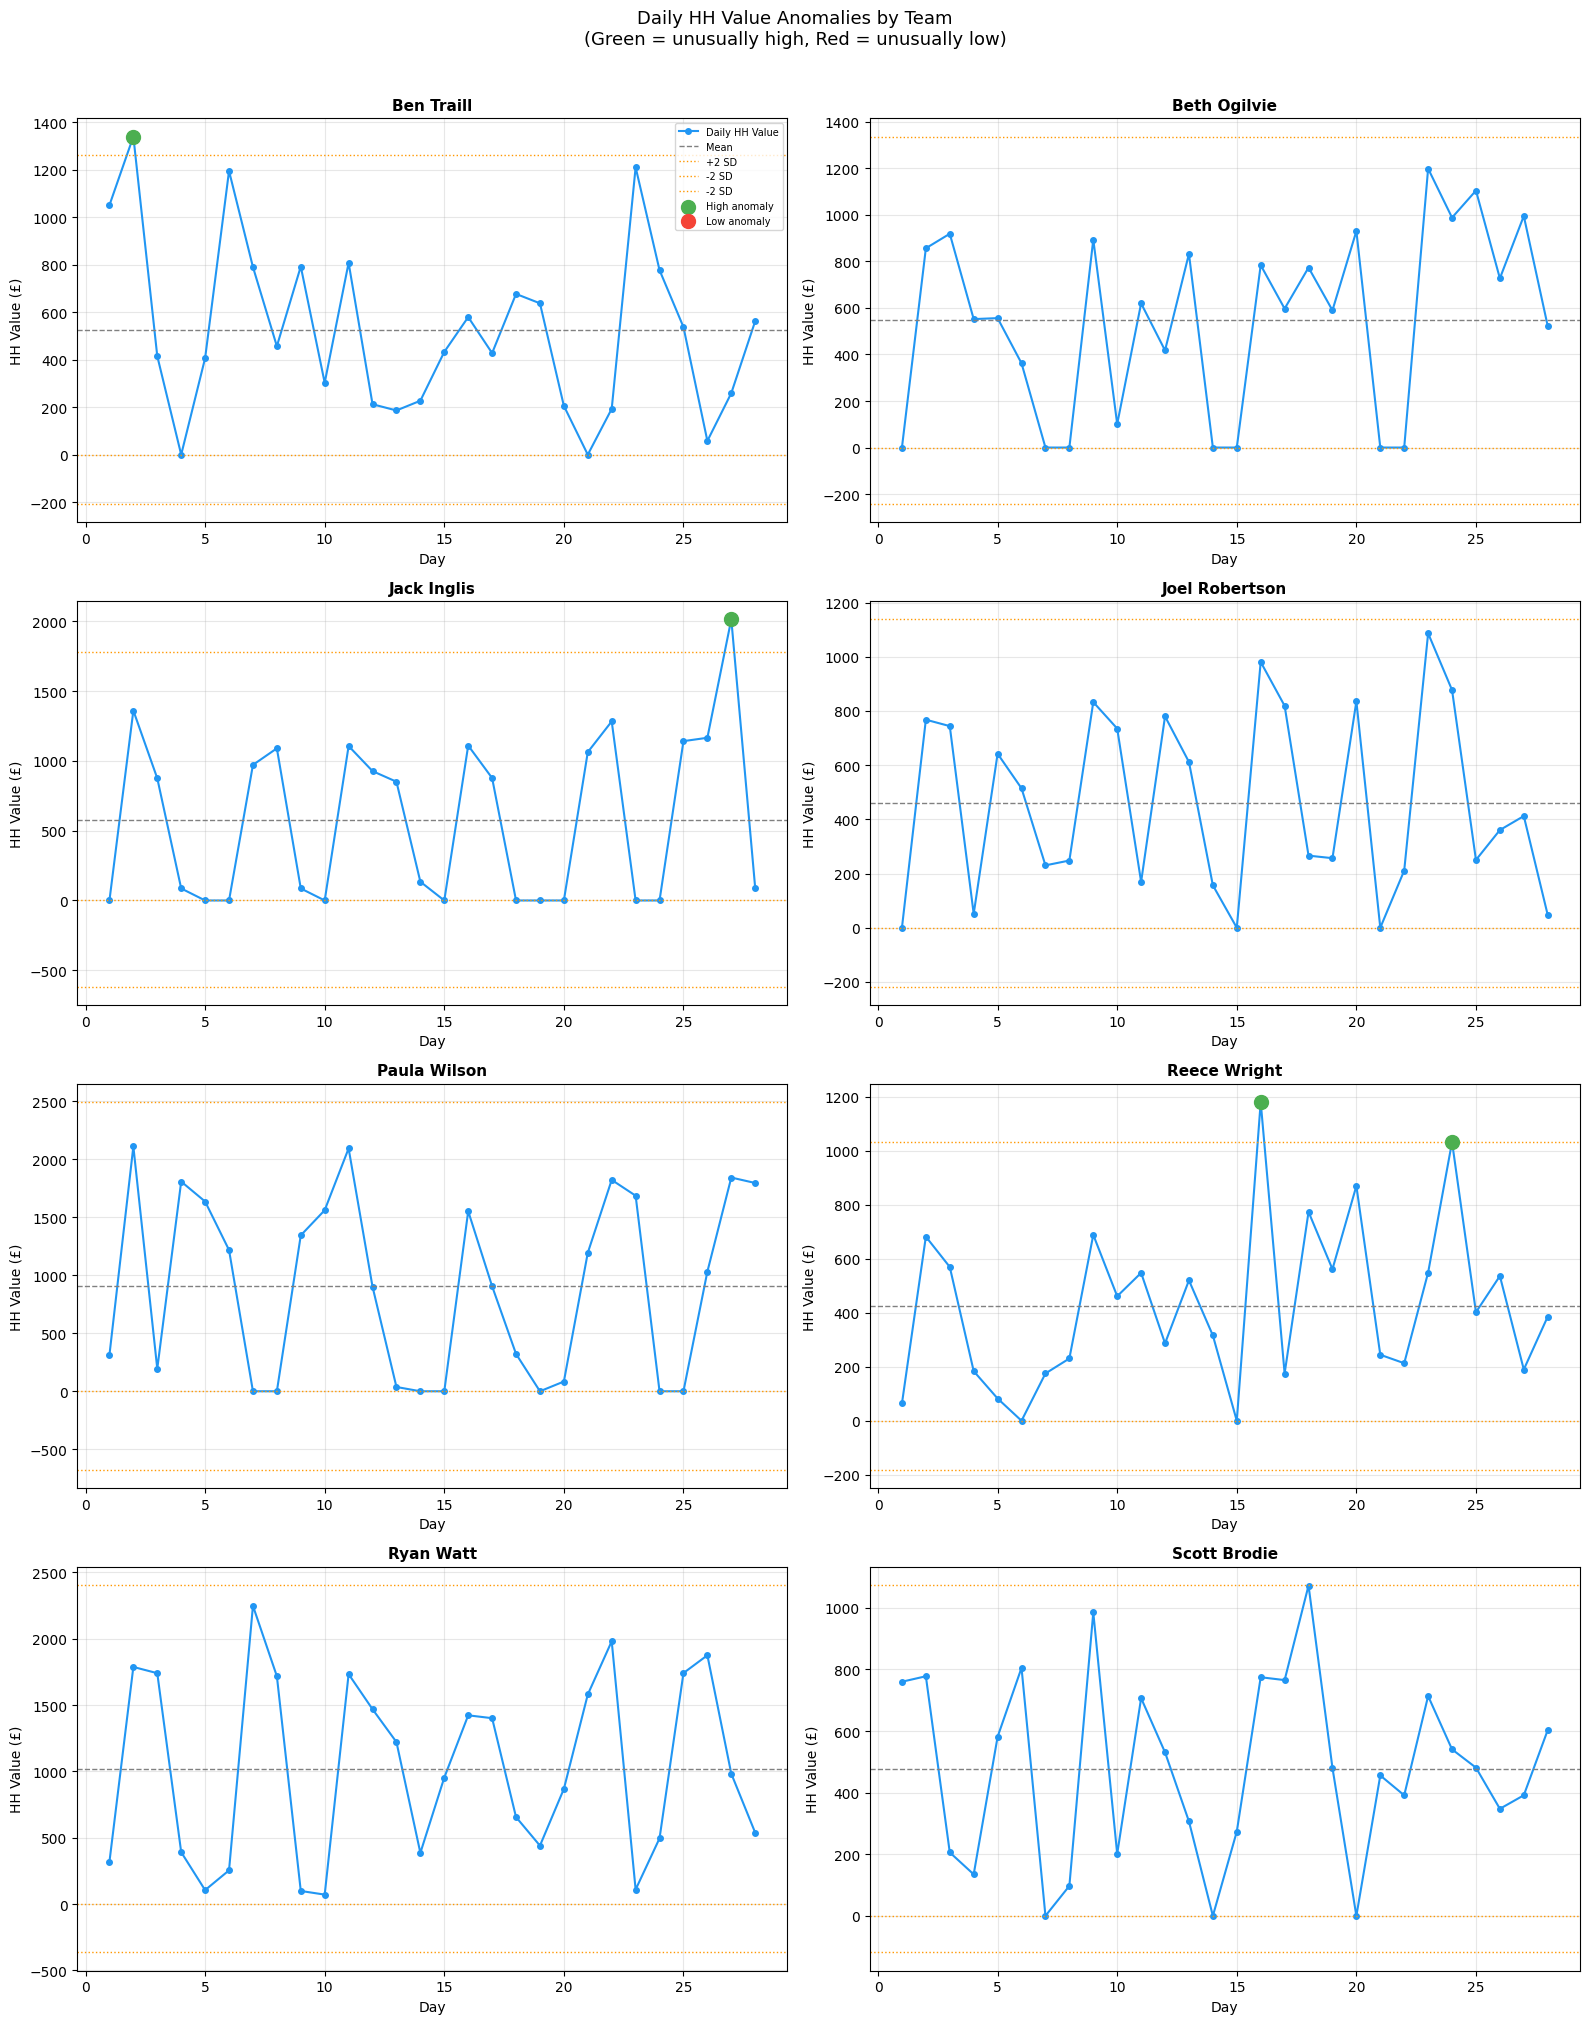

In [5]:
teams = sorted(df['team'].unique())
n_teams = len(teams)

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, team in enumerate(teams):
    team_df = df[df['team'] == team].sort_values('day')
    ax = axes[i]

    # Plot daily HH value
    ax.plot(team_df['day'], team_df['hh_value'], 
            color='#2196F3', linewidth=1.5, marker='o', markersize=4, label='Daily HH Value')

    # Add mean and ±2 std bands
    mean  = team_df['mean_hh_value'].iloc[0]
    std   = team_df['std_hh_value'].iloc[0]
    ax.axhline(mean, color='grey', linestyle='--', linewidth=1, label='Mean')
    ax.axhline(mean + 2*std, color='#FF9800', linestyle=':', linewidth=1, label='+2 SD')
    ax.axhline(mean - 2*std, color='#FF9800', linestyle=':', linewidth=1, label='-2 SD')
    ax.axhline(max(0, mean - 2*std), color='#FF9800', linestyle=':', linewidth=1, label='-2 SD')

    # Highlight anomalous days
    high = team_df[team_df['is_high_anomaly']]
    low  = team_df[team_df['is_low_anomaly']]
    ax.scatter(high['day'], high['hh_value'], color='#4CAF50', s=100, zorder=5, label='High anomaly')
    ax.scatter(low['day'],  low['hh_value'],  color='#F44336', s=100, zorder=5, label='Low anomaly')

    ax.set_title(team, fontsize=11, fontweight='bold')
    ax.set_xlabel('Day')
    ax.set_ylabel('HH Value (£)')
    ax.grid(alpha=0.3)

    if i == 0:
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Daily HH Value Anomalies by Team\n(Green = unusually high, Red = unusually low)', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/clean/anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()

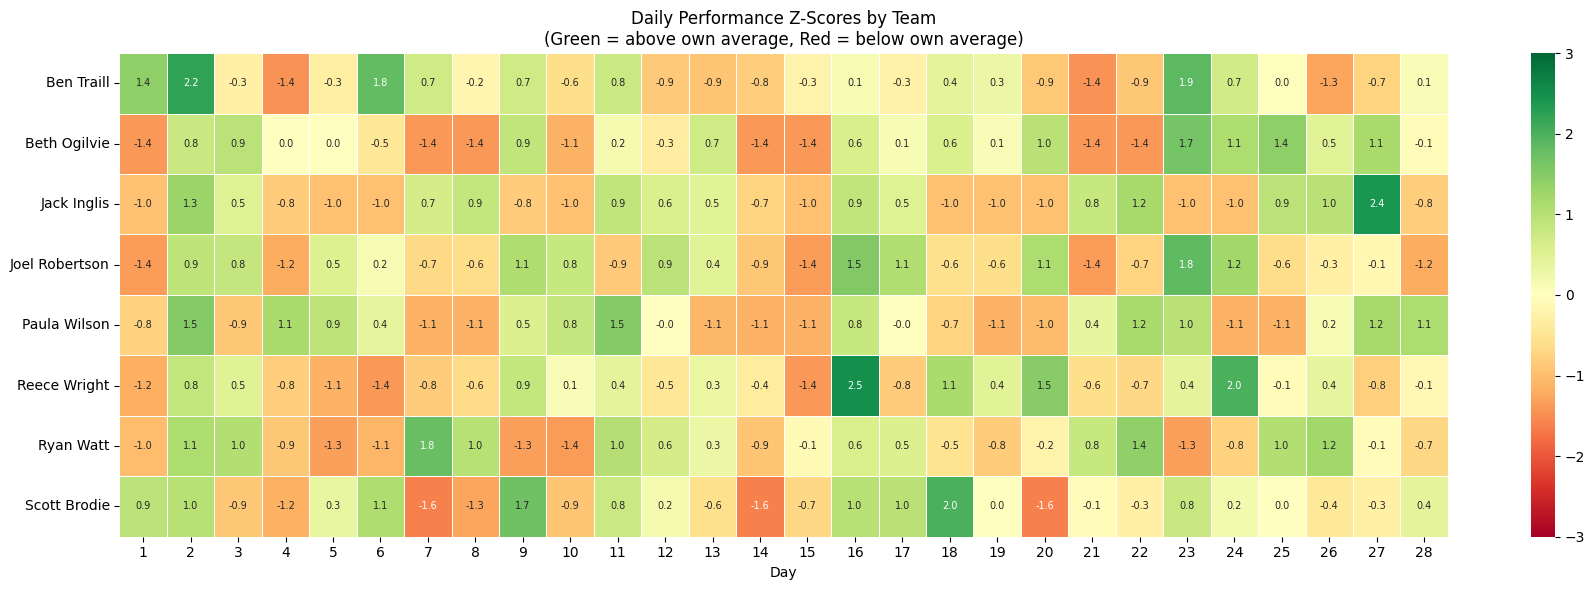

In [7]:
# Pivot z-scores into a heatmap so you can see anomalous days across all teams at once
zscore_pivot = df.pivot_table(
    index='team',
    columns='day',
    values='hh_value_zscore'
)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    zscore_pivot,
    cmap='RdYlGn',
    center=0,
    vmin=-3,
    vmax=3,
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Daily Performance Z-Scores by Team\n(Green = above own average, Red = below own average)', 
             fontsize=12)
ax.set_xlabel('Day')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../data/clean/zscore_heatmap.png', dpi=150)
plt.show()

## Anomaly Detection Methodology

Z-score based anomaly detection was applied to each team's daily HH value 
independently. Using team-level baselines rather than centre-wide averages 
ensures that a naturally lower-volume team is not permanently flagged as 
anomalous simply because they operate at a different scale.

A threshold of ±2 standard deviations was chosen as this captures 
approximately the most extreme 5% of observations under a normal 
distribution — unusual enough to warrant attention without generating 
excessive false positives.

### Operational Use Case
In a deployed setting, this logic could run automatically each evening 
and flag teams whose day falls below -2 SD for a manager review. 
Equally, high anomaly days (+2 SD) are worth investigating to understand 
what drove the exceptional performance and whether it can be replicated.